In [1]:
# ==========================================
# CELL 1: DATA GATHERING
# Download NLTK WordNet and define common idioms
# ==========================================
import json
import nltk
from nltk.corpus import wordnet as wn

print("Downloading WordNet data...")
nltk.download('wordnet')
nltk.download('omw-1.4')

idioms_list = [
    "piece of cake", "egg on my face", "break a leg", "hit the sack", "on the ball", 
    "under the weather", "bite the bullet", "cut corners", "add insult to injury", 
    "burn the midnight oil", "spill the beans", "beat around the bush", "call it a day",
    "get out of hand", "hang in there", "pull yourself together", "so far so good",
    "speak of the devil", "wrap my head around", "time flies", "break the ice",
    "cost an arm and a leg", "let the cat out of the bag", "once in a blue moon",
    "a blessing in disguise", "a dime a dozen", "beat the clock", "better late than never",
    "bite the dust", "cut the mustard", "cry over spilt milk", "every cloud has a silver lining",
    "get a taste of your own medicine", "give the benefit of the doubt", "go the extra mile",
    "hit the nail on the head", "ignorance is bliss", "it takes two to tango", "jump on the bandwagon",
    "keep your chin up", "kill two birds with one stone", "leave no stone unturned",
    "let sleeping dogs lie", "make a long story short", "miss the boat", "no pain no gain",
    "on thin ice", "out of the blue", "play devil's advocate", "pull someone's leg",
    "rain on someone's parade", "rule of thumb", "saved by the bell", "see eye to eye",
    "steal someone's thunder", "take it with a grain of salt", "the best of both worlds",
    "the elephant in the room", "the last straw", "the whole nine yards", "throw caution to the wind",
    "under the bridge", "up in the air", "water under the bridge", "weather the storm",
    "when pigs fly", "wild goose chase", "wrap your head around", "you can say that again",
    "figure out", "give up", "look forward to", "put up with", "run out of", 
    "look up to", "bring up", "call off", "carry on", "catch up", "come across",
    "drop by", "fall apart", "get along", "get away with", "give in", "go ahead",
    "grow up", "hold on", "keep up with", "look after", "make up", "pass away",
    "pass out", "point out", "put off", "run into", "set up", "show off",
    "show up", "take after", "take care of", "take off", "take over", "turn down",
    "turn into", "turn out", "turn up", "work out", "back up", "blow up", "break down",
    "break in", "break out", "break up", "bring about", "bring down", "bring in",
    "bring out", "call for", "care for", "catch on", "check in", "check out",
    "cheer up", "clean up", "come about", "come along", "come back", "come by",
    "come down", "come out", "come over", "come up", "count on", "cross out",
    "cut down", "cut off", "cut out", "do over", "drop in", "drop off",
    "drop out", "eat out", "end up", "fall behind", "fall down", "fall through",
    "fill in", "fill out", "fill up", "find out", "get across", "get around",
    "get back", "get by", "get in", "get off", "get on", "get out", "get over",
    "get through", "get up", "give away", "give back", "give out", "go after",
    "go along", "go away", "go back", "go down", "go off", "go on", "go out",
    "go over", "go through", "go up", "hand in", "hand out", "hand over",
    "hang out", "hang up", "hold back", "keep on", "let down", "look back",
    "look down on", "look for", "look into", "look out", "look over", "make out",
    "pay back", "pick out", "pick up", "pull down", "pull out",
    "put away", "put down", "put on", "put out", "put together", "run away",
    "run over", "send back", "set down", "set off", "set out", "sit down",
    "sit up", "stand for", "stand out", "stand up", "take apart", "take back"
]

print("Extracting Hard Words...")
hard_words = set()
for synset in wn.all_synsets():
    for lemma in synset.lemmas():
        word = lemma.name().replace('_', ' ').lower()
        if len(word) > 7:
            hard_words.add(word)

hard_words = list(hard_words)[:60000]

with open('idioms.json', 'w') as f:
    json.dump(idioms_list, f)
with open('hard_words.json', 'w') as f:
    json.dump(hard_words, f)
    
print(f"Saved {len(idioms_list)} Idioms and {len(hard_words)} Hard Words!")

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


Extracting Hard Words...
Saved 214 Idioms and 60000 Hard Words!


In [2]:
# ==========================================
# CELL 2: ADVANCED DATASET GENERATION
# Use NLTK Brown Corpus to generate 100k unique real-world sentences
# ==========================================
import json
import random
import nltk
from tqdm import tqdm
import pandas as pd
from datasets import Dataset

print("Downloading Brown Corpus...")
nltk.download('brown')
from nltk.corpus import brown

real_sentences = [sent for sent in brown.sents() if 5 < len(sent) < 20]
random.seed(42)

dataset_list = []

def create_ner_data(target_phrase, entity_type):
    sent = random.choice(real_sentences).copy()
    insert_idx = random.randint(0, len(sent) - 1)
    target_words = target_phrase.split()
    
    new_words = sent[:insert_idx] + target_words + sent[insert_idx:]
    
    labels = ['O'] * len(new_words)
    labels[insert_idx] = f'B-{entity_type}'
    for i in range(1, len(target_words)):
        labels[insert_idx + i] = f'I-{entity_type}'
        
    return {"tokens": new_words, "ner_tags": labels}

print("Generating 50,000 Idiom Sentences...")
for _ in tqdm(range(50000)):
    idiom = random.choice(idioms_list)
    dataset_list.append(create_ner_data(idiom, 'IDIOM'))

print("Generating 50,000 Hard Word Sentences...")
for _ in tqdm(range(50000)):
    w = random.choice(hard_words)
    dataset_list.append(create_ner_data(w, 'HARD_WORD'))

random.shuffle(dataset_list)

label_list = ['O', 'B-IDIOM', 'I-IDIOM', 'B-HARD_WORD', 'I-HARD_WORD']
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}

def align_labels_to_ids(example):
    example['ner_tags'] = [label2id[tag] for tag in example['ner_tags']]
    return example

df = pd.DataFrame(dataset_list)
dataset = Dataset.from_pandas(df)
dataset = dataset.map(align_labels_to_ids)

# Split Dataset
train_test = dataset.train_test_split(test_size=0.1)
train_dataset = train_test['train']
eval_dataset = train_test['test']

print("Massive Dataset Ready!")

[nltk_data] Downloading package brown to /usr/share/nltk_data...
[nltk_data]   Package brown is already up-to-date!


Generating 50,000 Idiom Sentences...


100%|██████████| 50000/50000 [00:00<00:00, 160375.02it/s]


Generating 50,000 Hard Word Sentences...


100%|██████████| 50000/50000 [00:01<00:00, 46518.88it/s] 


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Massive Dataset Ready!


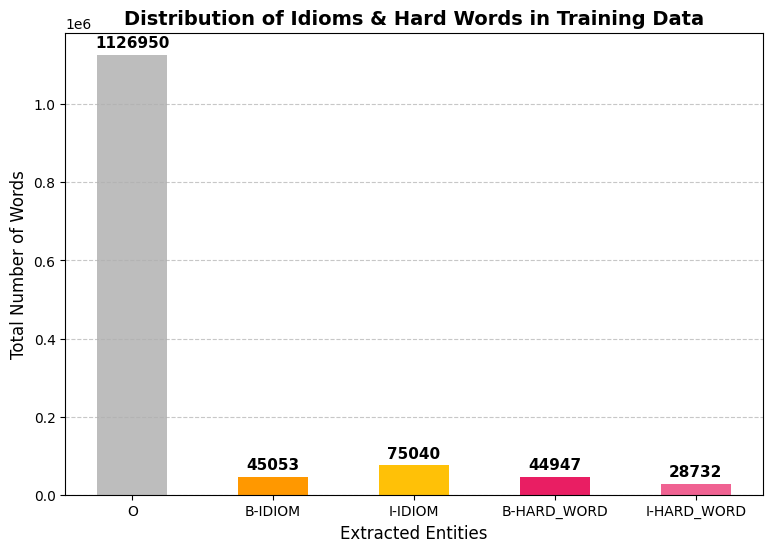

In [3]:
# ==========================================
# CELL 3: DATA VISUALIZATION
# Plot the distribution of Idioms vs Hard Words vs Normal tokens
# ==========================================
import matplotlib.pyplot as plt

all_tags = [tag for sentence_tags in train_dataset["ner_tags"] for tag in sentence_tags]
tag_counts = {label_list[i]: all_tags.count(i) for i in range(len(label_list))}

plt.figure(figsize=(9, 6))
colors = ['#BDBDBD', '#FF9800', '#FFC107', '#E91E63', '#F06292']
bars = plt.bar(tag_counts.keys(), tag_counts.values(), color=colors, width=0.5)

plt.xlabel('Extracted Entities', fontsize=12)
plt.ylabel('Total Number of Words', fontsize=12)
plt.title('Distribution of Idioms & Hard Words in Training Data', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(tag_counts.values()) * 0.01), 
             int(yval), ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()

In [4]:
# ==========================================
# CELL 4: TOKENIZATION & ALIGNMENT
# Initialize the tokenizer and align the IOB labels with sub-word tokens
# ==========================================
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True, max_length=128)
    labels = []
    
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100) 
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx]) 
            else:
                label_ids.append(-100) 
            previous_word_idx = word_idx
        labels.append(label_ids)
        
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_train = train_dataset.map(tokenize_and_align_labels, batched=True)
tokenized_eval = eval_dataset.map(tokenize_and_align_labels, batched=True)

print("Tokenization and label alignment completed!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/90000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Tokenization and label alignment completed!


In [7]:
!pip install --upgrade pip setuptools wheel
!pip install evaluate seqeval

# ==========================================
# CELL 5: EVALUATION METRICS
# Load the 'seqeval' metric to evaluate NER accuracy
# ==========================================
import evaluate
import numpy as np

seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_predictions = [[label_list[p] for (p, l) in zip(prediction, label) if l != -100] for prediction, label in zip(predictions, labels)]
    true_labels = [[label_list[l] for (p, l) in zip(prediction, label) if l != -100] for prediction, label in zip(predictions, labels)]
    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }
print("Metrics function defined successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 38.3 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting uninstall: setuptools
    Found existing installation: setuptools 81.0.0
    Uninstalling setuptools-81.0.0:
      Successfully uninstalled setuptools-81.0.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Using cached evaluate-0.4.6-py3-none-any.whl.metadata (9.5 kB)
  Using cached seqeval-1.2.2.tar.gz (43 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16251 

Metrics function defined successfully!


In [8]:
# ==========================================
# CELL 6: MODEL INITIALIZATION & TRAINING
# Initialize Token Classifier and start HuggingFace Trainer
# ==========================================
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer
from transformers import DataCollatorForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    model_name, 
    num_labels=len(label_list),
    id2label=id2label, 
    label2id=label2id
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./idiom_model_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    fp16=True, 
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting model training...")
trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting model training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4221, training_loss=0.0606690569953087, metrics={'train_runtime': 662.5834, 'train_samples_per_second': 407.496, 'train_steps_per_second': 6.371, 'total_flos': 2168420133185664.0, 'train_loss': 0.0606690569953087, 'epoch': 3.0})

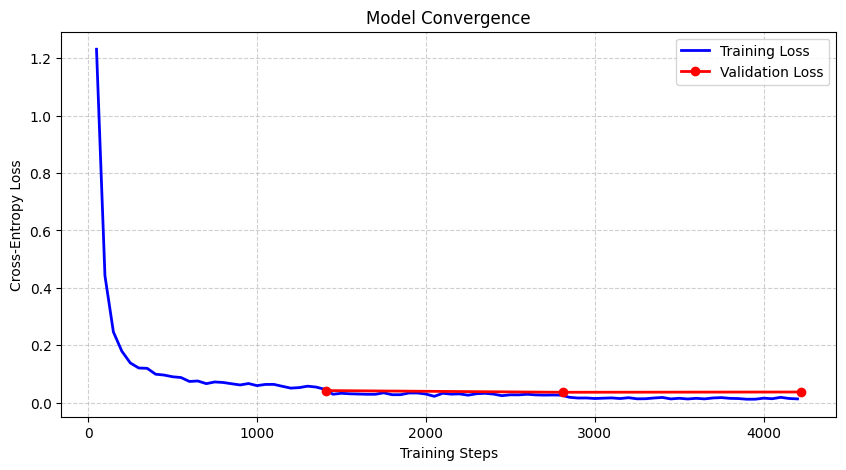

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


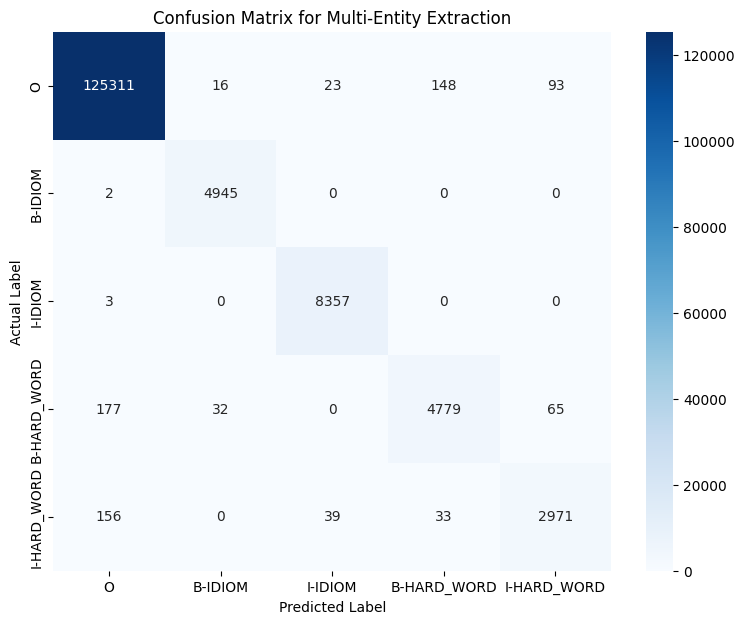

In [9]:
# ==========================================
# CELL 7: TRAINING GRAPHS & CONFUSION MATRIX
# Plot Model Convergence (Loss) and Confusion Matrix
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

history = trainer.state.log_history
train_loss = [log['loss'] for log in history if 'loss' in log]
train_steps = [log['step'] for log in history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]
eval_steps = [log['step'] for log in history if 'eval_loss' in log]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label='Training Loss', color='blue', linewidth=2)
if eval_loss:
    plt.plot(eval_steps, eval_loss, label='Validation Loss', color='red', marker='o', linewidth=2)
plt.xlabel('Training Steps')
plt.ylabel('Cross-Entropy Loss')
plt.title('Model Convergence')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

predictions, labels, _ = trainer.predict(tokenized_eval)
predictions = np.argmax(predictions, axis=2)
true_preds = []
true_labels = []
for pred, label in zip(predictions, labels):
    for p, l in zip(pred, label):
        if l != -100:
            true_preds.append(p)
            true_labels.append(l)

cm = confusion_matrix(true_labels, true_preds, labels=list(range(len(label_list))))
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix for Multi-Entity Extraction')
plt.show()

In [10]:
# ==========================================
# CELL 8: SAVE & EXPORT MODEL
# Save the fine-tuned model and zip it for download
# ==========================================
import os
from IPython.display import display, FileLink

save_dir = "./idiom_phrase_model"
os.makedirs(save_dir, exist_ok=True)

trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

print("Model successfully saved locally! Zipping for download...")

!zip -r idiom_phrase_model.zip ./idiom_phrase_model

display(FileLink(r'idiom_phrase_model.zip'))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model successfully saved locally! Zipping for download...
  adding: idiom_phrase_model/ (stored 0%)
  adding: idiom_phrase_model/training_args.bin (deflated 53%)
  adding: idiom_phrase_model/config.json (deflated 51%)
  adding: idiom_phrase_model/tokenizer.json (deflated 71%)
  adding: idiom_phrase_model/tokenizer_config.json (deflated 42%)
  adding: idiom_phrase_model/model.safetensors (deflated 8%)


/kaggle/working/idiom_phrase_model.zip